In [7]:
import pandas as pd
from pathlib import Path
# from urllib.parse import quote

# Change this to the waypoint file you want to use
area_name = 'Cottonwood_Fire'  # must match the survey notebook
# The survey notebook writes into the repo's plans/<area>/ folder; this
# notebook lives in notebooks/, hence the '..'.
plan_dir = Path('..') / 'plans' / area_name
plan_dir.mkdir(parents=True, exist_ok=True)
csv_file = plan_dir / f'{area_name}_waypoints_foreflight.csv'
origin_airport = 'KBOI'  # Change this to your origin
destination_airport = 'KBOI'  # Change this to your destination
survey_altitude = '180' # survery altitude in 100 feet increments (e.g., 180 = 18,000 feet)

# Read the ForeFlight waypoint CSV
waypoints = pd.read_csv(csv_file)

# Build a plain-text route string that ForeFlight can read from email
# Format: APT@KBOI + waypoint1 + waypoint2 + ... + APT@KBOI
parts = []
for _, row in waypoints.iterrows():
    lat = float(row['LAT'])
    lon = float(row['LONG'])
    lat_dir = 'N' if lat >= 0 else 'S'
    lon_dir = 'E' if lon >= 0 else 'W'
    parts.append(f"{abs(lat):.4f}{lat_dir}/{abs(lon):.4f}{lon_dir}/F{survey_altitude}")

route_text = 'APT@' + origin_airport + '+' + '+'.join(parts) + '+' + destination_airport

# Optional: create a foreflightmobile:// URL that opens the route in the app
foreflight_url = f'foreflightmobile://maps/search?q={route_text}'

print('Route text for email:')
print(route_text)
print('\nForeFlight URL:')
print(foreflight_url)


Route text for email:
APT@KBOI+38.1500N/112.6800W/F180+38.1500N/112.2000W/F180+38.2136N/112.2000W/F180+38.2136N/112.6800W/F180+38.2770N/112.6800W/F180+38.2770N/112.2000W/F180+38.3405N/112.2000W/F180+38.3405N/112.6800W/F180+38.4039N/112.6800W/F180+38.4039N/112.2000W/F180+KBOI

ForeFlight URL:
foreflightmobile://maps/search?q=APT@KBOI+38.1500N/112.6800W/F180+38.1500N/112.2000W/F180+38.2136N/112.2000W/F180+38.2136N/112.6800W/F180+38.2770N/112.6800W/F180+38.2770N/112.2000W/F180+38.3405N/112.2000W/F180+38.3405N/112.6800W/F180+38.4039N/112.6800W/F180+38.4039N/112.2000W/F180+KBOI


Note: you may need to restart the kernel to use updated packages.
Saved QR code to foreflight_route_qr.png


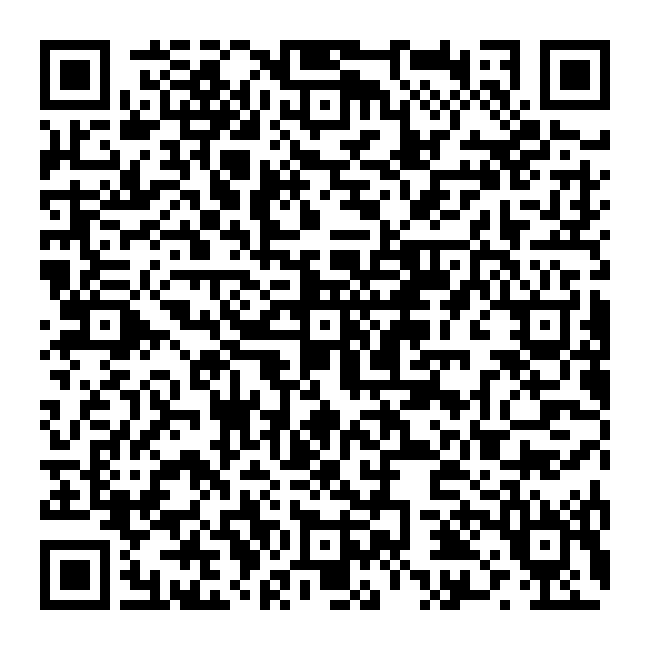

In [10]:
%pip install 'qrcode[pil]'

import qrcode
from IPython.display import display

qr = qrcode.QRCode(version=1, box_size=10, border=4)
qr.add_data(foreflight_url)
qr.make(fit=True)
img = qr.make_image(fill_color='black', back_color='white')

output_path = plan_dir / 'foreflight_route_qr.png'
img.save(output_path)
print(f'Saved QR code to {output_path}')
display(img)
